In [4]:
import numpy as np
import pydicom
import matplotlib.pyplot as plt

print("pydicom version:", pydicom.__version__)

pydicom version: 3.0.2


In [6]:
from pydicom.data import get_testdata_file

path = get_testdata_file('CT_small.dcm')
ds = pydicom.dcmread(path)

print(type(ds))

<class 'pydicom.dataset.FileDataset'>


In [7]:
print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 192
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.5962.2
(0002,0013) Implementation Version Name         SH: 'DCTOOL100'
(0002,0016) Source Application Entity Title     AE: 'CLUNIE1'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation Date              DA: '20040119'
(0008,0013) Instance Creation Time              TM: '072731'
(0008,0014) Instance Creator UID                UI: 1.3.6.1.4.

In [9]:
def safe_get(ds, attribute, default="NOT PRESENT"):
    return getattr(ds, attribute, default)

print("Modality:         ", safe_get(ds, 'Modality'))
print("Rows x Cols:      ", ds.Rows, "x", ds.Columns)
print("Pixel Spacing:    ", safe_get(ds, 'PixelSpacing'))
print("Bits Allocated:   ", safe_get(ds, 'BitsAllocated'))
print("Bits Stored:      ", safe_get(ds, 'BitsStored'))
print("Rescale Slope:    ", safe_get(ds, 'RescaleSlope'))
print("Rescale Intercept:", safe_get(ds, 'RescaleIntercept'))
print("Window Center:    ", safe_get(ds, 'WindowCenter'))
print("Window Width:     ", safe_get(ds, 'WindowWidth'))

Modality:          CT
Rows x Cols:       128 x 128
Pixel Spacing:     [0.661468, 0.661468]
Bits Allocated:    16
Bits Stored:       16
Rescale Slope:     1
Rescale Intercept: -1024
Window Center:     NOT PRESENT
Window Width:      NOT PRESENT


In [10]:
pixel_array = ds.pixel_array

print("Shape:", pixel_array.shape)
print("Dtype:", pixel_array.dtype)
print("Min:", pixel_array.min())
print("Max:", pixel_array.max())

Shape: (128, 128)
Dtype: int16
Min: 128
Max: 2191


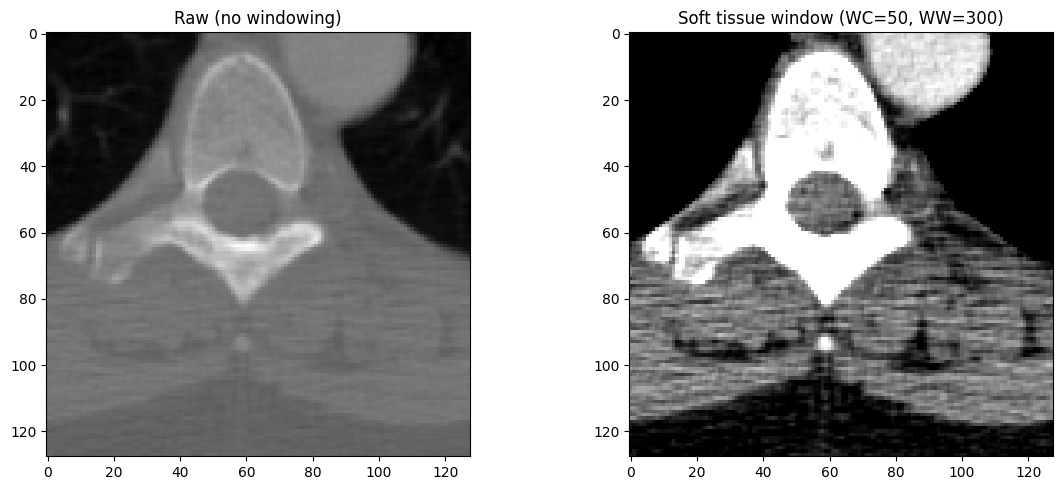

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(pixel_array, cmap='gray')
axes[0].set_title('Raw (no windowing)')

wc = 50
ww = 300
low = wc - ww / 2
high = wc + ww / 2
windowed = np.clip(pixel_array - 1024, low, high)

axes[1].imshow(windowed, cmap='gray')
axes[1].set_title(f'Soft tissue window (WC={wc}, WW={ww})')

plt.tight_layout()
plt.show()

In [15]:
hu_array = pixel_array * ds.RescaleSlope + ds.RescaleIntercept

print("HU min:", hu_array.min())
print("HU max:", hu_array.max())

HU min: -896.0
HU max: 1167.0


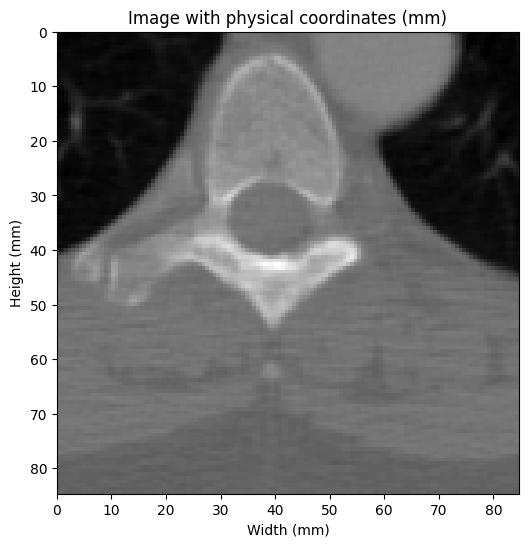

In [16]:
row_spacing, col_spacing = [float(x) for x in ds.PixelSpacing]
physical_height = ds.Rows * row_spacing
physical_width = ds.Columns * col_spacing

plt.figure(figsize=(6, 6))
plt.imshow(pixel_array, cmap='gray', extent=[0, physical_width, physical_height, 0])
plt.xlabel('Width (mm)')
plt.ylabel('Height (mm)')
plt.title('Image with physical coordinates (mm)')
plt.show()